In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [3]:
df = pd.read_csv("Dataset.csv")


In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

# Level 1 – Data Analysis Internship (Cognifyz)

## Overview
This notebook contains Level 1 tasks of the Cognifyz Data Analysis Internship.  
The objective is to perform exploratory data analysis on a restaurant dataset to uncover patterns related to cuisines, city-wise distribution, pricing trends, and online delivery impact.

## Dataset Description
The dataset includes information such as:
- Restaurant location (City)
- Cuisines offered
- Aggregate ratings and votes
- Price range
- Availability of online delivery

The analysis is divided into four tasks as specified in Level 1 guidelines.

## Level 1 – Task 1: Top Cuisines

### Objective
The goal of this task is to:
- Identify the top three most common cuisines served by restaurants.
- Calculate the percentage of restaurants offering each of these cuisines.

This helps in understanding dominant food preferences in the dataset.

In [7]:
cuisine_series = df['Cuisines'].dropna().str.split(', ')
all_cuisines = cuisine_series.explode()


In [8]:
top_cuisines = all_cuisines.value_counts().head(3)
top_cuisines

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [9]:
total_restaurants = len(df)
top_cuisine_percent = (top_cuisines / total_restaurants) * 100
top_cuisine_percent


Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64

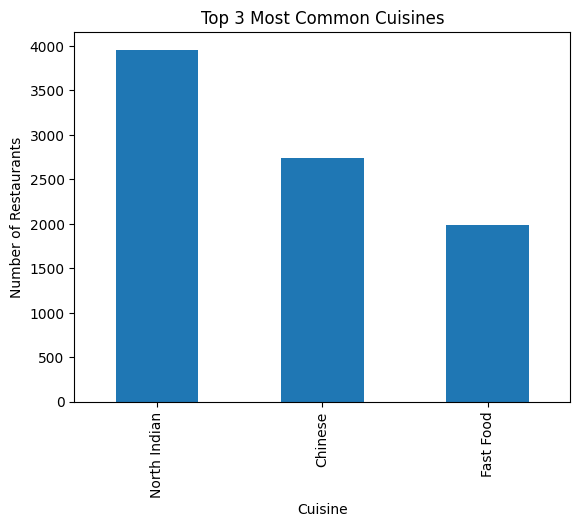

In [10]:
top_cuisines.plot(kind='bar')
plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.show()


### Insights
The analysis shows that a small set of cuisines dominates the restaurant landscape.  
This indicates strong customer demand concentration around popular cuisines. Restaurants offering these cuisines are likely to attract higher footfall and enjoy better market visibility.

## Level 1 – Task 2: City Analysis

### Objective
This task focuses on:
- Identifying the city with the highest number of restaurants.
- Calculating the average restaurant rating for each city.
- Determining the city with the highest average rating.

This analysis highlights geographical concentration and quality variations across cities.

In [11]:
city_counts = df['City'].value_counts()
city_counts.head()


City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

In [12]:
city_avg_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
city_avg_rating.head()


City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64

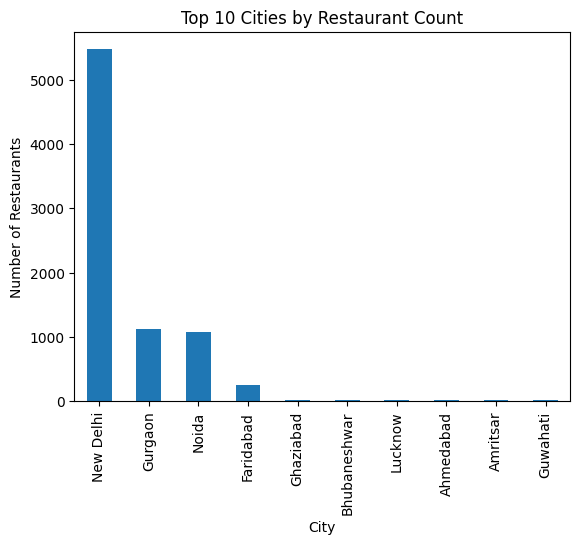

In [13]:
city_counts.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()


### Insights
The results reveal that some cities have a high concentration of restaurants, indicating competitive markets.  
However, cities with fewer restaurants sometimes show higher average ratings, suggesting that quality does not always correlate with quantity.

## Level 1 – Task 3: Price Range Distribution

### Objective
The purpose of this task is to:
- Analyze the distribution of restaurants across different price ranges.
- Calculate the percentage of restaurants in each price category.

This helps assess affordability trends and customer targeting strategies.

In [14]:
price_dist = df['Price range'].value_counts().sort_index()
price_dist


Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [15]:
(price_dist / total_restaurants) * 100


Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64

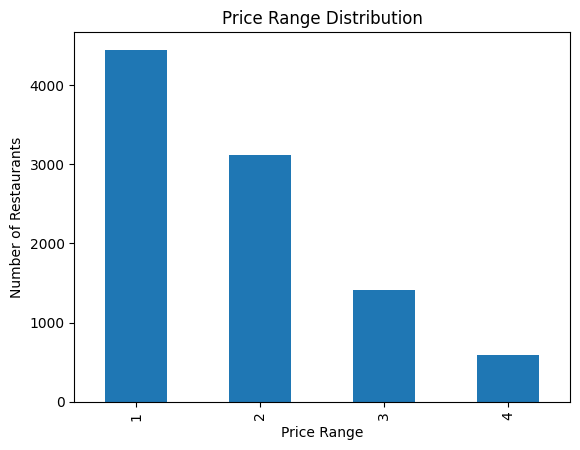

In [16]:
price_dist.plot(kind='bar')
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()


### Insights
The majority of restaurants fall within lower to mid price ranges, indicating a market focus on affordability.  
This suggests that budget-friendly dining options dominate, likely due to broader customer demand and accessibility.

## Level 1 – Task 4: Online Delivery Analysis

### Objective
This task aims to:
- Determine the percentage of restaurants offering online delivery.
- Compare the average ratings of restaurants with and without online delivery.

The objective is to understand the impact of digital convenience on customer ratings.

In [17]:
delivery_counts = df['Has Online delivery'].value_counts()
delivery_percentage = (delivery_counts / total_restaurants) * 100
delivery_percentage


Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64

In [18]:
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
delivery_rating


Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

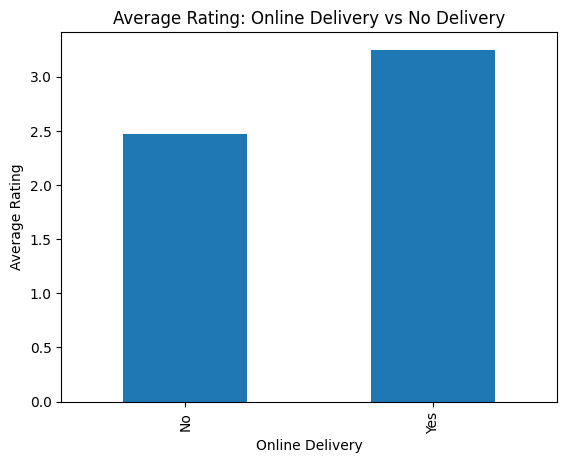

In [19]:
delivery_rating.plot(kind='bar')
plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.show()


### Insights
Restaurants offering online delivery generally show slightly higher average ratings.  
This suggests that convenience and accessibility play an important role in customer satisfaction and overall restaurant perception.

## Level 1 – Final Summary

This Level 1 analysis explored cuisine popularity, city-wise restaurant distribution, pricing patterns, and the influence of online delivery on ratings.

Key findings include strong dominance of specific cuisines, high restaurant concentration in select cities, a preference for affordable dining options, and a positive association between online delivery availability and customer ratings. These insights provide a foundational understanding of market trends within the restaurant dataset.